In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\Aditi Sinha\OneDrive\Documents\Data Analysis\netflix_customer_churn.csv")

In [5]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [6]:
df.shape

(5000, 14)

In [7]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

In [9]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [10]:
df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [11]:
df["subscription_type"].value_counts()

subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

In [12]:
df.groupby("subscription_type")["churned"].mean()

subscription_type
Basic       0.618302
Premium     0.437094
Standard    0.454435
Name: churned, dtype: float64

In [13]:
df.groupby("subscription_type")["churned"].agg(["count", "sum", "mean"])

,count,sum,mean
subscription_type,,,
Basic,1661,1027,0.618302
Premium,1693,740,0.437094
Standard,1646,748,0.454435


In [14]:
pd.crosstab(df["subscription_type"], df["churned"])

churned,0,1
subscription_type,,
Basic,634,1027
Premium,953,740
Standard,898,748


In [15]:
df["watch_hours"].describe()

count    5000.000000
mean       11.649450
std        12.014654
min         0.010000
25%         3.337500
50%         8.000000
75%        16.030000
max       110.400000
Name: watch_hours, dtype: float64

In [16]:
df["watch_group"]= pd.qcut(
    df["watch_hours"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

In [17]:
df["watch_group"].value_counts()

watch_group
Medium-Low     1251
Low            1250
Medium-High    1250
High           1249
Name: count, dtype: int64

In [18]:
df.groupby("watch_group")["churned"].mean()

watch_group
Low            0.856000
Medium-Low     0.589129
Medium-High    0.436000
High           0.130504
Name: churned, dtype: float64

In [19]:
df.groupby(["watch_group","subscription_type"])["churned"].mean()

watch_group  subscription_type
Low          Basic                0.973494
             Premium              0.794749
             Standard             0.800481
Medium-Low   Basic                0.738208
             Premium              0.500000
             Standard             0.525060
Medium-High  Basic                0.543326
             Premium              0.382284
             Standard             0.378173
High         Basic                0.197468
             Premium              0.089245
             Standard             0.110312
Name: churned, dtype: float64

In [20]:
df["login_group"]= pd.cut(
    df["last_login_days"],
    bins = [0,7,30,60,float("inf")],
    include_lowest = True,
    labels = ["Very_active", "Active", "At_risk", "Highly_inactive"]
)

In [21]:
df["login_group"].value_counts()

login_group
At_risk            2469
Active             1881
Very_active         650
Highly_inactive       0
Name: count, dtype: int64

In [22]:
df["last_login_days"].describe()

count    5000.000000
mean       30.089800
std        17.536078
min         0.000000
25%        15.000000
50%        30.000000
75%        45.000000
max        60.000000
Name: last_login_days, dtype: float64

In [38]:
df.groupby("login_group")["churned"].mean()

login_group
Very_active    0.133846
Active         0.305157
At_risk        0.750911
Name: churned, dtype: float64

In [23]:
df.groupby(["login_group", "subscription_type"])["churned"].mean()

login_group  subscription_type
Very_active  Basic                0.266355
             Premium              0.073733
             Standard             0.063927
Active       Basic                0.395425
             Premium              0.243531
             Standard             0.281046
At_risk      Basic                0.871856
             Premium              0.688645
             Standard             0.689571
Name: churned, dtype: float64

In [24]:
df.groupby(["login_group", "subscription_type"])["churned"].agg(["count","sum","mean"])

count  sum      mean
login_group subscription_type                      
Very_active Basic                214   57  0.266355
            Premium              217   16  0.073733
            Standard             219   14  0.063927
Active      Basic                612  242  0.395425
            Premium              657  160  0.243531
            Standard             612  172  0.281046
At_risk     Basic                835  728  0.871856
            Premium              819  564  0.688645
            Standard             815  562  0.689571

In [44]:
df["region"].value_counts()

region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

In [48]:
df.groupby("region")["churned"].mean()

region
Africa           0.483188
Asia             0.506540
Europe           0.516724
North America    0.494712
Oceania          0.500654
South America    0.514318
Name: churned, dtype: float64

In [49]:
df.groupby(["login_group","region"])["churned"].mean()

login_group  region       
Very_active  Africa           0.120370
             Asia             0.177570
             Europe           0.064220
             North America    0.097345
             Oceania          0.194444
             South America    0.152381
Active       Africa           0.326019
             Asia             0.283489
             Europe           0.311321
             North America    0.292359
             Oceania          0.297297
             South America    0.319018
At_risk      Africa           0.720745
             Asia             0.765133
             Europe           0.777273
             North America    0.736842
             Oceania          0.759003
             South America    0.744344
Name: churned, dtype: float64

In [51]:
df.groupby(["login_group","region"])["churned"].agg(["count", "sum", "mean"])

count  sum      mean
login_group region                             
Very_active Africa           108   13  0.120370
            Asia             107   19  0.177570
            Europe           109    7  0.064220
            North America    113   11  0.097345
            Oceania          108   21  0.194444
            South America    105   16  0.152381
Active      Africa           319  104  0.326019
            Asia             321   91  0.283489
            Europe           318   99  0.311321
            North America    301   88  0.292359
            Oceania          296   88  0.297297
            South America    326  104  0.319018
At_risk     Africa           376  271  0.720745
            Asia             413  316  0.765133
            Europe           440  342  0.777273
            North America    437  322  0.736842
            Oceania          361  274  0.759003
            South America    442  329  0.744344

In [52]:
df["age"].describe()

count    5000.000000
mean       43.847400
std        15.501128
min        18.000000
25%        30.000000
50%        44.000000
75%        58.000000
max        70.000000
Name: age, dtype: float64

In [55]:
df["age_group"] = pd.cut(
    df["age"],
    bins = [18,30,44,58,70],
    include_lowest = True,
    labels = ["Young", "Young-mid", "Mid-older", "Older"]
)

In [56]:
df["age_group"].value_counts()

age_group
Mid-older    1293
Young-mid    1284
Young        1270
Older        1153
Name: count, dtype: int64

In [57]:
df.groupby("age_group")["churned"].mean()

age_group
Young        0.508661
Young-mid    0.486760
Mid-older    0.529002
Older        0.485690
Name: churned, dtype: float64

In [58]:
df.groupby(["age_group", "subscription_type"])["churned"].mean()

age_group  subscription_type
Young      Basic                0.646766
           Premium              0.427273
           Standard             0.462617
Young-mid  Basic                0.581986
           Premium              0.414692
           Standard             0.461538
Mid-older  Basic                0.621076
           Premium              0.491031
           Standard             0.468828
Older      Basic                0.626316
           Premium              0.410390
           Standard             0.422680
Name: churned, dtype: float64

In [25]:
cols_to_check = ["payment_method", "number_of_profiles", "device", "favorite_genre", "gender"]

for col in cols_to_check:
    print(f"--- Churn Rate by {col} ---")
    print(df.groupby(col)["churned"].agg(["count", "mean"]))
    print("\n")

--- Churn Rate by payment_method ---
                count      mean
payment_method                 
Credit Card       973  0.435766
Crypto            995  0.596985
Debit Card       1030  0.436893
Gift Card         976  0.577869
PayPal           1026  0.470760


--- Churn Rate by number_of_profiles ---
                    count      mean
number_of_profiles                 
1                     972  0.586420
2                    1001  0.574426
3                     994  0.578471
4                     999  0.375375
5                    1034  0.406190


--- Churn Rate by device ---
         count      mean
device                  
Desktop    949  0.492097
Laptop    1006  0.517893
Mobile    1004  0.504980
TV         993  0.499496
Tablet    1048  0.500000


--- Churn Rate by favorite_genre ---
                count      mean
favorite_genre                 
Action            697  0.523673
Comedy            685  0.499270
Documentary       729  0.507545
Drama             731  0.522572
Horror 

In [27]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Aditi Sinha\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a stylish theme for clean, professional charts
sns.set_theme(style="whitegrid")

C:\Users\Aditi Sinha\AppData\Local\Temp\ipykernel_24488\1813495383.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Aditi Sinha\AppData\Local\Temp\ipykernel_24488\1813495383.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Aditi Sinha\AppData\Local\Temp\ipykernel_24488\1813495383.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


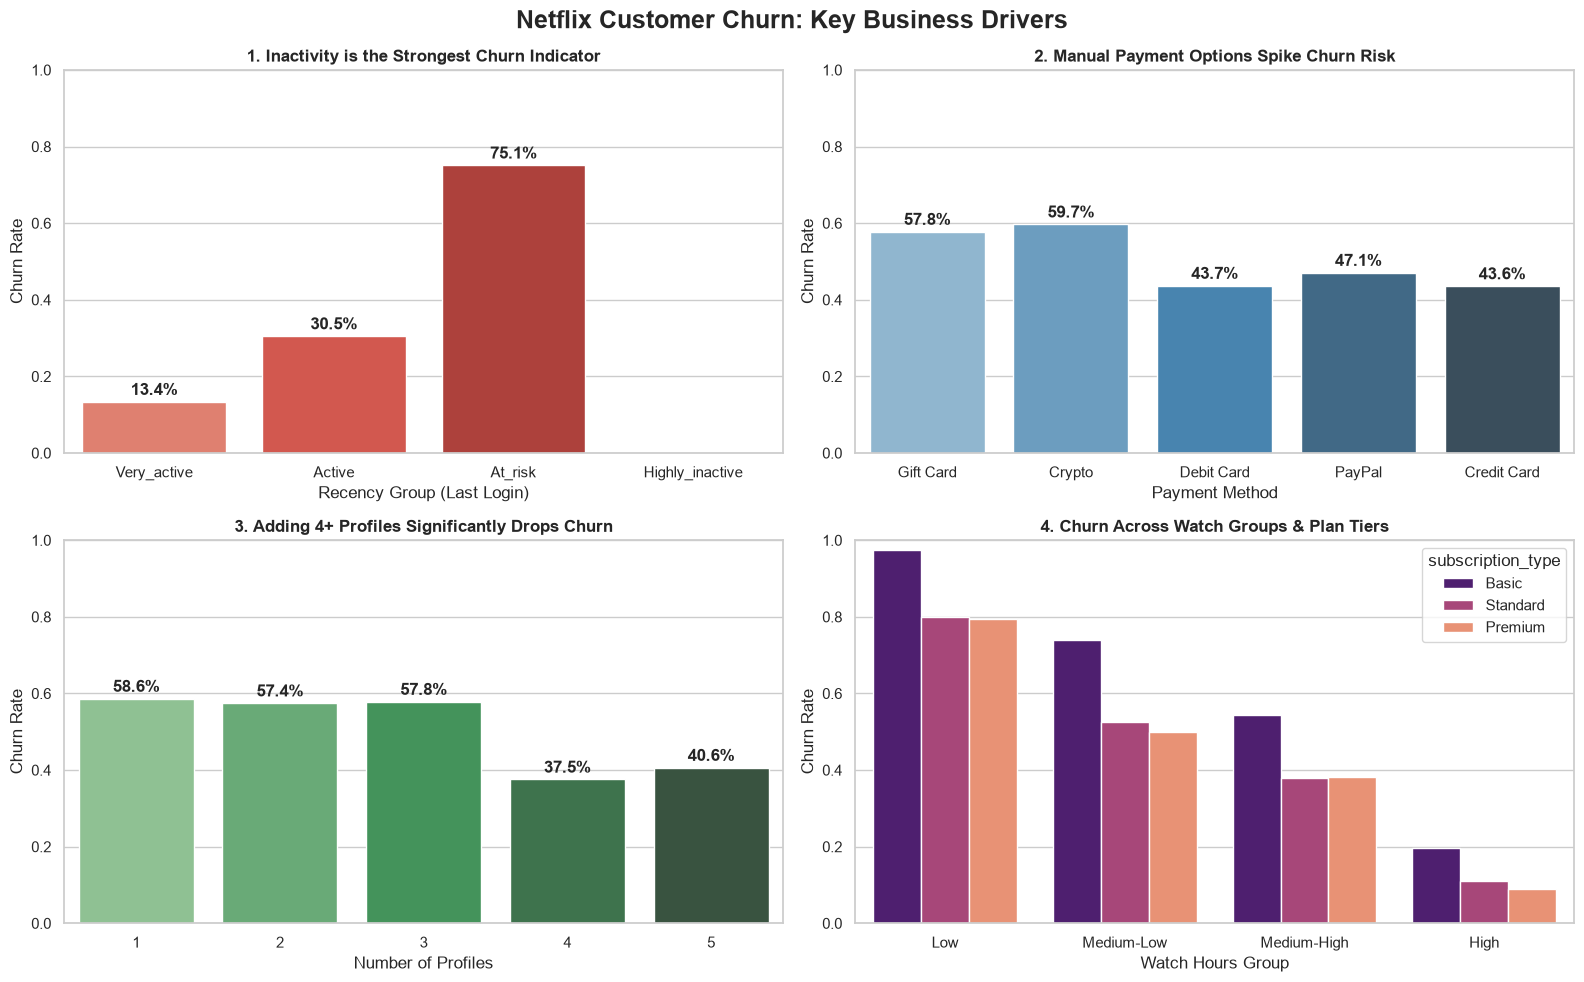

In [29]:
# Set up a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Netflix Customer Churn: Key Business Drivers",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

# ----------------------------------------------------
# Chart 1: Churn by Last Login Recency (Engagement)
# ----------------------------------------------------
sns.barplot(
    data=df,
    x="login_group",
    y="churned",
    ax=axes[0, 0],
    palette="Reds_d",
    errorbar=None,
)
axes[0, 0].set_title("1. Inactivity is the Strongest Churn Indicator", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Recency Group (Last Login)")
axes[0, 0].set_ylabel("Churn Rate")
axes[0, 0].set_ylim(0, 1)

# Add exact percentage labels on top of bars
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )

# ----------------------------------------------------
# Chart 2: Churn by Payment Method
# ----------------------------------------------------
sns.barplot(
    data=df,
    x="payment_method",
    y="churned",
    ax=axes[0, 1],
    palette="Blues_d",
    errorbar=None,
)
axes[0, 1].set_title("2. Manual Payment Options Spike Churn Risk", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Payment Method")
axes[0, 1].set_ylabel("Churn Rate")
axes[0, 1].set_ylim(0, 1)

for p in axes[0, 1].patches:
    axes[0, 1].annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )

# ----------------------------------------------------
# Chart 3: Churn by Number of Profiles (Account Stickiness)
# ----------------------------------------------------
sns.barplot(
    data=df,
    x="number_of_profiles",
    y="churned",
    ax=axes[1, 0],
    palette="Greens_d",
    errorbar=None,
)
axes[1, 0].set_title("3. Adding 4+ Profiles Significantly Drops Churn", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Number of Profiles")
axes[1, 0].set_ylabel("Churn Rate")
axes[1, 0].set_ylim(0, 1)

for p in axes[1, 0].patches:
    axes[1, 0].annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )

# ----------------------------------------------------
# Chart 4: Watch Hours vs. Subscription Tier
# ----------------------------------------------------
sns.barplot(
    data=df,
    x="watch_group",
    y="churned",
    hue="subscription_type",
    ax=axes[1, 1],
    palette="magma",
    errorbar=None,
)
axes[1, 1].set_title("4. Churn Across Watch Groups & Plan Tiers", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Watch Hours Group")
axes[1, 1].set_ylabel("Churn Rate")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

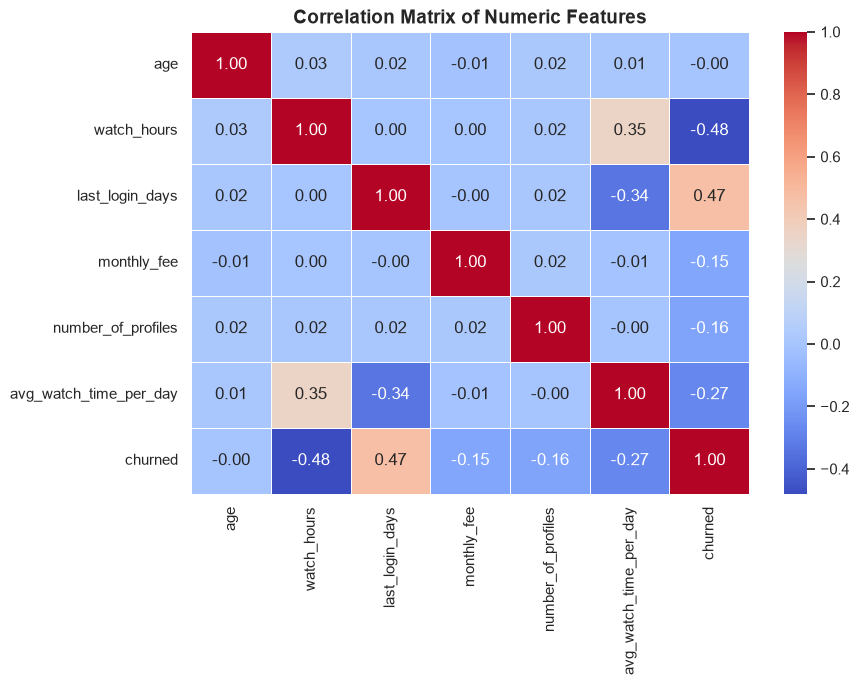

In [30]:
plt.figure(figsize=(9, 6))

# Select continuous numeric columns
numeric_cols = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "churned",
]

# Compute correlation and plot heatmap
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold")
plt.show()